# Eksperiment 3-4 - Razlika rangova + razlika formi SMA(5)

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from experiment_utils import run_one_experiment, run, save_result_v1, MLPClassifier

import warnings
warnings.filterwarnings('ignore')

## Podaci

In [6]:
df = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['date'] = pd.to_datetime(df['date'], format='mixed')
df = df.sort_values('date').reset_index(drop=True)

print(f'Ukupno meceva: {len(df)}')
print(df['result'].value_counts())

Ukupno meceva: 1239
result
 1    582
-1    371
 0    286
Name: count, dtype: int64


## SMA(5) i razlika formi

In [7]:
home_rows = df[['date', 'home_team', 'result']].rename(columns={'home_team': 'team', 'result': 'team_result'})
away_rows = df[['date', 'away_team', 'result']].copy()
away_rows['team_result'] = -away_rows['result']
away_rows = away_rows[['date', 'away_team', 'team_result']].rename(columns={'away_team': 'team'})

team_results = pd.concat([home_rows, away_rows]).sort_values('date').reset_index(drop=True)
team_results['sma5'] = (
    team_results.groupby('team')['team_result']
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

df = df.merge(team_results.rename(columns={'team': 'home_team', 'sma5': 'home_form_sma5'})[['date', 'home_team', 'home_form_sma5']], on=['date', 'home_team'], how='left')
df = df.merge(team_results.rename(columns={'team': 'away_team', 'sma5': 'away_form_sma5'})[['date', 'away_team', 'away_form_sma5']], on=['date', 'away_team'], how='left')
df = df.dropna(subset=['home_form_sma5', 'away_form_sma5', 'elo_advantage']).reset_index(drop=True)

df['form_diff_sma5'] = df['home_form_sma5'] - df['away_form_sma5']
print(f'Meceva nakon filtriranja: {len(df)}')

Meceva nakon filtriranja: 614


## Priprema i pokretanje

In [8]:
X = df[["rank_advantage", 'elo_advantage', 'form_diff_sma5']].values
le = LabelEncoder()
y = le.fit_transform(df['result'].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)

In [10]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_t.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8065 | val loss = 0.9033 | val acc = 0.5152
Epoch 100/1000 | train loss = 0.7962 | val loss = 0.9120 | val acc = 0.5152
Epoch 150/1000 | train loss = 0.7707 | val loss = 0.9214 | val acc = 0.4949
Epoch 200/1000 | train loss = 0.7759 | val loss = 0.9330 | val acc = 0.5051
Epoch 250/1000 | train loss = 0.7666 | val loss = 0.9334 | val acc = 0.5152
Epoch 300/1000 | train loss = 0.7611 | val loss = 0.9245 | val acc = 0.4949
Epoch 350/1000 | train loss = 0.7651 | val loss = 0.9520 | val acc = 0.5051
Epoch 400/1000 | train loss = 0.7652 | val loss = 0.9509 | val acc = 0.5051
Epoch 450/1000 | train loss = 0.7400 | val loss = 0.9608 | val acc = 0.5051
Epoch 500/1000 | train loss = 0.7394 | val loss = 0.9844 | val acc = 0.5152
Epoch 550/1000 | train loss = 0.7113 | val loss = 0.9899 | val acc = 0.5051
Epoch 600/1000 | train loss = 0.7477 | val loss = 0.9739 | val acc = 0.5354
Epoch 650/1000 | train loss = 0.7256 | val loss = 1.0083 | val acc = 0.5455
Epoch 700/100

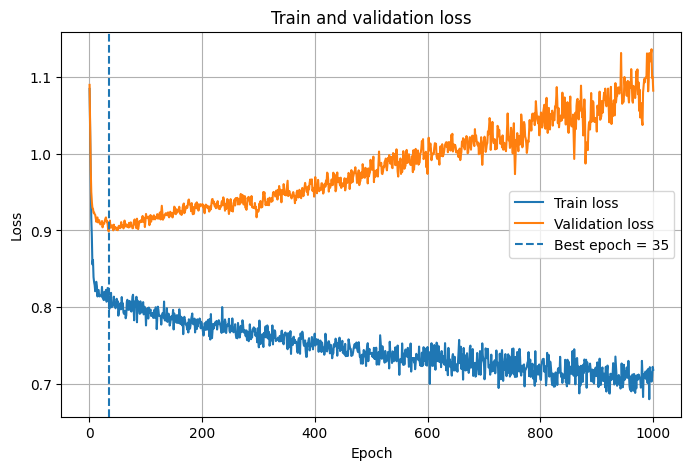

0.6016260162601627

In [11]:
run_one_experiment(model, criterion, optimizer, X_train_t, y_train_t, X_test_t, y_test_t)

In [12]:
best_num_epochs = 35

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_t,
    y_train_tensor=y_train_t,
    X_test_tensor=X_test_t,
    y_test_tensor=y_test_t,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6016 | Precision: 0.3894 | Recall: 0.5205 | Specificity: 0.7764 | F1: 0.4455

Run 2/10
Accuracy: 0.5935 | Precision: 0.3831 | Recall: 0.5148 | Specificity: 0.7742 | F1: 0.4392

Run 3/10
Accuracy: 0.6016 | Precision: 0.3883 | Recall: 0.5205 | Specificity: 0.7779 | F1: 0.4448

Run 4/10
Accuracy: 0.6016 | Precision: 0.3883 | Recall: 0.5205 | Specificity: 0.7779 | F1: 0.4448

Run 5/10
Accuracy: 0.5854 | Precision: 0.3788 | Recall: 0.5092 | Specificity: 0.7690 | F1: 0.4343

Run 6/10
Accuracy: 0.5935 | Precision: 0.3831 | Recall: 0.5148 | Specificity: 0.7742 | F1: 0.4392

Run 7/10
Accuracy: 0.6016 | Precision: 0.3883 | Recall: 0.5205 | Specificity: 0.7779 | F1: 0.4448

Run 8/10
Accuracy: 0.5935 | Precision: 0.3831 | Recall: 0.5148 | Specificity: 0.7742 | F1: 0.4392

Run 9/10
Accuracy: 0.5854 | Precision: 0.3816 | Recall: 0.5092 | Specificity: 0.7706 | F1: 0.4361

Run 10/10
Accuracy: 0.5935 | Precision: 0.3868 | Recall: 0.5148 | Specificity: 0.7743 | F1: 0.4417

Summary o

In [14]:
save_result_v1(
    experiment_name="Experiment_3-4_ranks_diff_SMA5_diff",
    summary=summary
)


Saved result for Experiment_3-4_ranks_diff_SMA5_diff
File: ../results/experiment_summary_v1.csv
